## Usar apenas se estiver rodando no Google Colab:

In [1]:
! git clone https://github.com/EduardoShoiti/tech-challenge-3
%cd tech-challenge-3

Cloning into 'tech-challenge-3'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 40 (delta 5), reused 21 (delta 5), pack-reused 13 (from 1)
Receiving objects: 100% (40/40), 176.44 MiB | 27.81 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/tech-challenge-3


In [ ]:
# ! pip install -r requirements.txt

In [2]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 15.1 MB/s eta 0:00:00


In [3]:
! ls

data  Notebooks  README.md  requirements.txt


## Rodando Local

In [1]:
! pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ------- -------------------------------- 7.9/41.9 MB 48.7 MB/s eta 0:00:01
   -------- ------------------------------- 8.7/41.9 MB 23.2 MB/s eta 0:00:02
   --------- ------------------------------ 9.4/41.9 MB 16.1 MB/s eta 0:00:03
   --------- ------------------------------ 10.2/41.9 MB 12.8 MB/s eta 0:00:03
   ---------- ----------------------------- 11.0/41.9 MB 10.9 MB/s eta 0:00:03
   ----------- ---------------------------- 11.8/41.9 MB 9.7 MB/s eta 0:00:04
   ------------ --------------------------- 12.6/41.9 MB 8.8 MB/s eta 0:00:04
   ------------ --------------------------- 13.4/41.9 MB 8.2 MB/s eta 0:00:04
   ------------- -------------------------- 14.2/41.9 MB 7.7 MB/s eta 0:00:04
   -------------- ------------------------- 14.9/41.9 MB 7.3 MB/s eta 0:00:04
   --------------- ------------------------ 15.7/41.9 MB 6.9 MB/s eta 0:00:04
   --------------- ------------------------ 16.5/41.9 MB 6.7 MB/s eta 


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ! pip install -r requirements.txt

## Utils

In [2]:
%pip check

No broken requirements found.
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)

from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)


PROJECT_DIR = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_PATH = PROJECT_DIR / 'data' / 'sample' / 'data_sample_modeling.parquet'
assert DATA_PATH.exists(), f'Arquivo não encontrado: {DATA_PATH.resolve()}'



c:\Users\Shoiti\Desktop\Shoiti\PosTech - AI Scientist\tech-challenge-3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
RANDOM_STATE = 42
TARGET = 'alfabetizado'

# Métrica usada pelo Optuna para comparar configurações.
# ROC AUC é independente do threshold e mede a capacidade de ranking/separação.
OPTUNA_SCORING = "roc_auc"

# Quantidade de folds utilizada dentro APENAS do conjunto de treino.
N_SPLITS_CV = 5

N_TRIALS = {
    "lr": 30,
    "dt": 40,
    "rf": 20,
    "lgbm": 25,
    "nb": 15,
}

In [5]:
df = pd.read_parquet(DATA_PATH)
df.shape, df['ano'].value_counts().sort_index(), df[TARGET].value_counts(normalize=True)

((386816, 55),
 ano
 2023    174743
 2024    212073
 Name: count, dtype: int64,
 alfabetizado
 1    0.51305
 0    0.48695
 Name: proportion, dtype: float64)

## Higienização: constantes e leakage

A função abaixo remove automaticamente colunas constantes no conjunto de treino. As colunas de ID, o alvo, o ano e as variáveis explicitamente listadas como leakage também são removidas. A lista é conservadora: taxas e médias de alfabetização/proficiência do mesmo ano podem incluir informação posterior ou o próprio aluno.

In [6]:
# Identificadores não generalizam para novos alunos/escolas; `ano` apenas define o corte temporal.
ID_COLUMNS = ['id_aluno', 'id_municipio', 'codigo_uf', 'rede']
TIME_COLUMN = 'ano'

# Medidas da prova ou agregados calculados no período do rótulo: candidatas a leakage.
LEAKAGE_COLUMNS = [
    'proficiencia', 'peso_aluno', 'presenca', 'preenchimento_caderno', 'caderno',
    'municipio_taxa_alfabetizacao_pct', 'municipio_media_portugues',
    'uf_taxa_alfabetizacao_pct', 'uf_media_portugues',
    'brasil_taxa_alfabetizacao_pct',
]

def columns_to_remove(frame, target=TARGET):
    fixed = set([target, TIME_COLUMN, *ID_COLUMNS, *LEAKAGE_COLUMNS])
    # Metas futuras não são atributos individuais e podem introduzir sinal temporal artificial.
    fixed.update(c for c in frame.columns if c.startswith('meta_'))
    constants = {c for c in frame.columns if frame[c].nunique(dropna=False) <= 1}
    return sorted((fixed | constants) & set(frame.columns)), sorted(constants)

# O ajuste da lista de constantes ocorre apenas em 2023, evitando inspecionar o teste.
df_2023 = df.loc[df[TIME_COLUMN] == 2023].copy()
remove_columns, constant_columns = columns_to_remove(df_2023)
print('Constantes em 2023:', constant_columns)
print('Colunas removidas:', remove_columns)

Constantes em 2023: ['ano', 'brasil_taxa_alfabetizacao_pct', 'meta_brasil_2024_pct', 'meta_brasil_2025_pct', 'meta_brasil_2026_pct', 'meta_brasil_2027_pct', 'meta_brasil_2028_pct', 'meta_brasil_2029_pct', 'meta_brasil_2030_pct', 'meta_brasil_percentual_participacao_pct', 'meta_uf_2030_pct', 'sem_gestor', 'serie']
Colunas removidas: ['alfabetizado', 'ano', 'brasil_taxa_alfabetizacao_pct', 'caderno', 'codigo_uf', 'id_aluno', 'id_municipio', 'meta_brasil_2024_pct', 'meta_brasil_2025_pct', 'meta_brasil_2026_pct', 'meta_brasil_2027_pct', 'meta_brasil_2028_pct', 'meta_brasil_2029_pct', 'meta_brasil_2030_pct', 'meta_brasil_percentual_participacao_pct', 'meta_municipio_2024_pct', 'meta_municipio_2025_pct', 'meta_municipio_2026_pct', 'meta_municipio_2027_pct', 'meta_municipio_2028_pct', 'meta_municipio_2029_pct', 'meta_municipio_2030_pct', 'meta_municipio_nivel_alfabetizacao', 'meta_municipio_percentual_participacao_pct', 'meta_municipio_taxa_alfabetizacao_pct', 'meta_uf_2024_pct', 'meta_uf_202

## Separação temporal

A validação é uma amostra estratificada de 2023, usada para comparar e calibrar modelos. O teste é 2024 completo e só deve ser consultado no final.

In [7]:
train_2023, valid_2023 = train_test_split(
    df_2023, test_size=0.20, stratify=df_2023[TARGET], random_state=RANDOM_STATE
)
test_2024 = df.loc[df[TIME_COLUMN] == 2024].copy()

FEATURES = [c for c in df.columns if c not in remove_columns]
X_train, y_train = train_2023[FEATURES], train_2023[TARGET]
X_val, y_val = valid_2023[FEATURES], valid_2023[TARGET]
X_test, y_test = test_2024[FEATURES], test_2024[TARGET]

pd.DataFrame({
    'conjunto': ['treino (2023)', 'validação (2023)', 'teste (2024)'],
    'linhas': [len(X_train), len(X_val), len(X_test)],
    'taxa_alfabetizado': [y_train.mean(), y_val.mean(), y_test.mean()]
})

datasets_dev = {
    "Treino": (
        X_train,
        y_train
    ),
    "Validação": (
        X_val,
        y_val
    )
}

datasets_test = {
    "Teste": (
        X_test,
        y_test
    )
}

In [8]:
X_train

,id_escola,sigla_uf,regiao,rede_desc,pib,populacao,recusa,caracterizacao_orgao_gestor,escolaridade,escolaridade_formacao
299768,60009244,CE,Nordeste,Municipal,9891544000,355679.0,0,Secretaria exclusiva,Ensino superior completo,Outra
49684,60024070,RJ,Sudeste,Municipal,3956993000,20373.0,0,Secretaria em conjunto com outras políticas se...,Ensino superior completo,Biologia
201130,60036456,SC,Sul,Municipal,45511051000,616317.0,0,Secretaria exclusiva,Mestrado,Administração
181737,60019437,MG,Sudeste,Municipal,635552000,27635.0,0,Secretaria exclusiva,Mestrado,Pedagogia
96072,60039675,RS,Sul,Municipal,4647664000,224124.0,0,Secretaria exclusiva,Especialização,Pedagogia
...,...,...,...,...,...,...,...,...,...,...
364346,60002271,PA,Norte,Municipal,1297602000,67585.0,0,Secretaria exclusiva,Ensino médio (2º Grau) completo,NaN
284475,60007581,CE,Nordeste,Municipal,71512000,7262.0,0,Secretaria exclusiva,Especialização,Letras
133584,60006457,PI,Nordeste,Municipal,25943688000,866300.0,0,Secretaria exclusiva,Doutorado,Outra
154491,60024057,RJ,Sudeste,Municipal,11663534000,129612.0,0,Secretaria exclusiva,Especialização,Educação física


## Pipelines reutilizáveis de pré-processamento

In [28]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.frequency_maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            self.frequency_maps_[col] = (
                X[col]
                .value_counts(normalize=True, dropna=False)
                .to_dict()
            )

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            X[col] = (
                X[col]
                .map(self.frequency_maps_[col])
                .fillna(0)
            )

        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

In [29]:
def create_preprocessor(
    onehot_cols=None,
    frequency_cols=None,
    standard_cols=None
):
    onehot_cols = onehot_cols or []
    frequency_cols = frequency_cols or []
    standard_cols = standard_cols or []

    transformers = []

    if onehot_cols:
        transformers.append(
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                onehot_cols
            )
        )

    if frequency_cols:
        transformers.append(
            (
                "frequency",
                FrequencyEncoder(),
                frequency_cols
            )
        )

    if standard_cols:
        transformers.append(
            (
                "standard",
                StandardScaler(),
                standard_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="passthrough",
        verbose_feature_names_out=False
    )

    return preprocessor

In [30]:
onehot_cols = [
    "regiao",
    "rede_desc",
    "escolaridade",
]

frequency_cols = [
    "id_escola",
    "sigla_uf",
    "caracterizacao_orgao_gestor",
    "escolaridade_formacao"
]

standard_cols = [
    "pib",
    "populacao"
]

In [31]:
preprocessor = create_preprocessor(
    onehot_cols=onehot_cols,
    frequency_cols=frequency_cols,
    standard_cols=standard_cols
)

## Função para avaliação do modelo

In [50]:
def evaluate_model(
    model,
    datasets,
    threshold="ks",
    min_precision=0.6,
    threshold_dataset="Validação",
    save_images=False,
    image_suffix=None,
    interpretability=False,
    interpretability_dataset=None,
    shap_sample_size=200,
    top_features=15
):
    """
    Avalia um modelo de classificação binária em um ou mais datasets.

    Pode ser utilizada tanto durante o desenvolvimento quanto
    na avaliação final do teste.

    Parameters
    ----------
    model : estimator ou sklearn Pipeline
        Modelo já treinado e com método predict_proba().

    datasets : dict
        Dicionário no formato:

        {
            "Treino": (X_train, y_train),
            "Validação": (X_val, y_val)
        }

        ou, para avaliação final:

        {
            "Teste": (X_test, y_test)
        }

    threshold : str ou float, default="ks"
        - "ks":
            encontra o threshold que maximiza o KS no
            dataset definido em `threshold_dataset`.

        - float:
            utiliza diretamente o threshold informado.

    threshold_dataset : str, default="Validação"
        Dataset utilizado para calcular o threshold KS.

        Normalmente deve ser "Validação".

        Não deve ser "Teste" no fluxo de desenvolvimento.

    save_images : bool, default=False
        Quando True, salva os gráficos na pasta `images`.

    image_suffix : str, optional
        Sufixo usado nos nomes dos arquivos. Obrigatório quando
        `save_images=True`; por exemplo, "LightGBM_val".

    interpretability : bool, default=False
        Quando True, calcula importância por permutação e SHAP.

    interpretability_dataset : str, optional
        Dataset usado na interpretabilidade. Por padrão usa
        `threshold_dataset` ou o primeiro dataset disponível.

    shap_sample_size : int, default=200
        Número máximo de observações utilizadas pelo SHAP.

    top_features : int, default=15
        Quantidade máxima de variáveis exibidas nos gráficos.

    Returns
    -------
    results_df : pandas.DataFrame
        Métricas calculadas para cada dataset.

    decision_threshold : float
        Threshold utilizado para gerar as classificações.
    """

    # Validações iniciais
    if not isinstance(datasets, dict):
        raise TypeError(
            "`datasets` deve ser um dicionário."
        )

    if len(datasets) == 0:
        raise ValueError(
            "`datasets` não pode estar vazio."
        )

    if save_images and not image_suffix:
        raise ValueError(
            "`image_suffix` é obrigatório quando `save_images=True`."
        )

    if save_images:
        images_dir = Path("images")
        images_dir.mkdir(parents=True, exist_ok=True)
        image_suffix = str(image_suffix).replace(" ", "_")

        def save_figure(figure, graph_name):
            file_path = images_dir / f"{graph_name}_{image_suffix}.png"
            figure.savefig(file_path, dpi=300, bbox_inches="tight")
            print(f"Gráfico salvo em: {file_path}")

    if interpretability_dataset is None:
        interpretability_dataset = (
            threshold_dataset
            if threshold_dataset in datasets
            else next(iter(datasets))
        )

    if interpretability and interpretability_dataset not in datasets:
        raise ValueError(
            f"O dataset '{interpretability_dataset}' não existe em `datasets`."
        )

    # Determinação do threshold
    if threshold in ["ks", "recall"]:

        if threshold_dataset not in datasets:
            raise ValueError(
                f"O dataset '{threshold_dataset}' não existe em "
                f"`datasets`.\n\n"
                f"Datasets disponíveis: {list(datasets.keys())}\n\n"
                f"Para avaliação final de teste, utilize o "
                f"threshold já definido na validação."
            )

        X_threshold, y_threshold = datasets[
            threshold_dataset
        ]

        y_threshold_proba = model.predict_proba(
            X_threshold
        )[:, 1]

        # =========================================================
        # Threshold pelo KS
        # =========================================================
        if threshold == "ks":

            fpr_threshold, tpr_threshold, thresholds = roc_curve(
                y_threshold,
                y_threshold_proba
            )

            # KS = TPR - FPR
            ks_values = (
                tpr_threshold
                - fpr_threshold
            )

            ks_idx = np.argmax(
                ks_values
            )

            decision_threshold = thresholds[
                ks_idx
            ]

            print(
                f"Threshold selecionado pelo KS "
                f"({threshold_dataset}): "
                f"{decision_threshold:.4f}"
            )

            print(
                f"KS máximo em {threshold_dataset}: "
                f"{ks_values[ks_idx]:.4f}"
            )

        # =========================================================
        # Threshold maximizando Recall
        # com Precision mínima
        # =========================================================
        elif threshold == "recall":

            precision_values, recall_values, thresholds = (
                precision_recall_curve(
                    y_threshold,
                    y_threshold_proba
                )
            )

            # precision_recall_curve retorna precision e recall
            # com 1 elemento a mais do que thresholds
            precision_values = precision_values[:-1]
            recall_values = recall_values[:-1]

            # Mantém somente thresholds que respeitam
            # a Precision mínima
            valid = (
                precision_values >= min_precision
            )

            if not np.any(valid):
                raise ValueError(
                    f"Nenhum threshold conseguiu atingir "
                    f"Precision >= {min_precision:.2%} "
                    f"em '{threshold_dataset}'."
                )

            valid_indices = np.where(
                valid
            )[0]

            # Entre os thresholds válidos,
            # escolhe aquele com maior Recall
            best_idx = valid_indices[
                np.argmax(
                    recall_values[valid]
                )
            ]

            decision_threshold = thresholds[
                best_idx
            ]

            selected_recall = recall_values[
                best_idx
            ]

            selected_precision = precision_values[
                best_idx
            ]

            print(
                f"Threshold selecionado para maximizar Recall "
                f"com Precision >= {min_precision:.0%} "
                f"({threshold_dataset}): "
                f"{decision_threshold:.4f}"
            )

            print(
                f"Recall em {threshold_dataset}: "
                f"{selected_recall:.4f}"
            )

            print(
                f"Precision em {threshold_dataset}: "
                f"{selected_precision:.4f}"
            )

    else:

        decision_threshold = float(
            threshold
        )

        if not 0 <= decision_threshold <= 1:
            raise ValueError(
                "O threshold deve estar entre 0 e 1."
            )

        print(
            f"Threshold fixo utilizado: "
            f"{decision_threshold:.4f}"
        )

    # Cálculo das métricas
    results = []
    predictions = {}

    for dataset_name, (X, y) in datasets.items():

        y_true = np.asarray(y)

        # Probabilidade da classe positiva
        y_proba = model.predict_proba(
            X
        )[:, 1]

        # Classe final
        y_pred = (
            y_proba >= decision_threshold
        ).astype(int)

        # Métricas dependentes do threshold
        recall = recall_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        # ROC / AUC
        auc = roc_auc_score(
            y_true,
            y_proba
        )

        fpr, tpr, roc_thresholds = roc_curve(
            y_true,
            y_proba
        )

        # KS
        ks_values = (
            tpr - fpr
        )

        ks_idx = np.argmax(
            ks_values
        )

        ks = ks_values[
            ks_idx
        ]

        ks_threshold = roc_thresholds[
            ks_idx
        ]

        # Precision-Recall
        (
            precision_curve,
            recall_curve,
            pr_thresholds
        ) = precision_recall_curve(
            y_true,
            y_proba
        )

        avg_precision = average_precision_score(
            y_true,
            y_proba
        )

        # Prevalência
        prevalence = np.mean(
            y_true
        )

        # Resultados
        results.append({
            "Dataset": dataset_name,
            "Recall": recall,
            "Precision": precision,
            "F1-Score": f1,
            "Accuracy": accuracy,
            "AUC": auc,
            "KS": ks,
            "Average Precision": avg_precision,
            "Prevalência": prevalence
        })

        predictions[dataset_name] = {

            "y_true": y_true,
            "y_pred": y_pred,
            "y_proba": y_proba,

            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,

            "ks_values": ks_values,
            "ks_idx": ks_idx,
            "ks_threshold": ks_threshold,

            "precision_curve": precision_curve,
            "recall_curve": recall_curve,
            "pr_thresholds": pr_thresholds,

            "prevalence": prevalence
        }

    # DataFrame de métricas
    results_df = (
        pd.DataFrame(results)
        .set_index("Dataset")
    )

    print("\nMétricas do modelo\n")

    try:

        display(
            results_df.style.format(
                "{:.4f}"
            )
        )

    except NameError:

        print(
            results_df.round(4)
        )

    # Matrizes de confusão
    n_datasets = len(
        predictions
    )

    fig, axes = plt.subplots(
        1,
        n_datasets,
        figsize=(
            5 * n_datasets,
            4
        )
    )

    # Quando há apenas 1 dataset, axes não é array
    if n_datasets == 1:
        axes = [axes]

    for ax, (
        dataset_name,
        values
    ) in zip(
        axes,
        predictions.items()
    ):

        cm = confusion_matrix(
            values["y_true"],
            values["y_pred"],
            normalize="true"
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        disp.plot(
            ax=ax,
            colorbar=False,
            values_format=".1%"
        )

        ax.set_title(
            f"Matriz de Confusão - "
            f"{dataset_name}"
        )

        ax.set_xlabel(
            "Classe predita"
        )

        ax.set_ylabel(
            "Classe real"
        )

    fig.suptitle(
        f"Matriz de Confusão "
        f"(Threshold = "
        f"{decision_threshold:.4f})",
        fontsize=14
    )

    plt.tight_layout()

    if save_images:
        save_figure(fig, "matriz_confusao")

    plt.show()

    # Curvas KS
    fig, axes = plt.subplots(
        1,
        n_datasets,
        figsize=(
            6 * n_datasets,
            5
        ),
        sharex=True,
        sharey=True
    )

    if n_datasets == 1:
        axes = [axes]

    for ax, (
        dataset_name,
        values
    ) in zip(
        axes,
        predictions.items()
    ):

        # Ordena scores do maior para o menor
        order = np.argsort(
            values["y_proba"]
        )[::-1]

        y_sorted = (
            values["y_true"][order]
        )

        n_positive = np.sum(
            y_sorted == 1
        )

        n_negative = np.sum(
            y_sorted == 0
        )

        # Distribuições acumuladas
        cum_positive = (
            np.cumsum(
                y_sorted == 1
            )
            / n_positive
        )

        cum_negative = (
            np.cumsum(
                y_sorted == 0
            )
            / n_negative
        )

        population = (
            np.arange(
                1,
                len(y_sorted) + 1
            )
            / len(y_sorted)
        )

        ks_curve = (
            cum_positive
            - cum_negative
        )

        ks_position = np.argmax(
            ks_curve
        )

        ks_value = ks_curve[
            ks_position
        ]

        ax.plot(
            population,
            cum_positive,
            label="Positivos"
        )

        ax.plot(
            population,
            cum_negative,
            label="Negativos"
        )

        ax.vlines(
            x=population[
                ks_position
            ],
            ymin=cum_negative[
                ks_position
            ],
            ymax=cum_positive[
                ks_position
            ],
            linestyles="--",
            label=f"KS = {ks_value:.4f}"
        )

        ax.set_title(
            f"KS - {dataset_name}"
        )

        ax.set_xlabel(
            "Proporção acumulada "
            "da população"
        )

        ax.set_ylabel(
            "Distribuição acumulada"
        )

        ax.set_xlim(
            0,
            1
        )

        ax.set_ylim(
            0,
            1
        )

        ax.grid(
            alpha=0.3
        )

        ax.legend()

    fig.suptitle(
        "Curvas KS",
        fontsize=14
    )

    plt.tight_layout()

    if save_images:
        save_figure(fig, "curvas_ks")

    plt.show()

    # Curvas ROC sobrepostas
    fig = plt.figure(
        figsize=(8, 6)
    )

    for (
        dataset_name,
        values
    ) in predictions.items():

        auc = results_df.loc[
            dataset_name,
            "AUC"
        ]

        plt.plot(
            values["fpr"],
            values["tpr"],
            label=(
                f"{dataset_name} "
                f"(AUC = {auc:.4f})"
            )
        )

    # Baseline aleatório
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Aleatório (AUC = 0.50)"
    )

    plt.title(
        "Curva ROC"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate / Recall"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    if save_images:
        save_figure(fig, "curva_roc")

    plt.show()

    # Precision-Recall sobrepostas
    fig = plt.figure(
        figsize=(8, 6)
    )

    for (
        dataset_name,
        values
    ) in predictions.items():

        avg_precision = results_df.loc[
            dataset_name,
            "Average Precision"
        ]

        plt.plot(
            values["recall_curve"],
            values["precision_curve"],
            label=(
                f"{dataset_name} "
                f"(AP = "
                f"{avg_precision:.4f})"
            )
        )

        # Baseline de cada conjunto
        plt.axhline(
            y=values["prevalence"],
            linestyle=":",
            alpha=0.5
        )

    plt.title(
        "Precision-Recall"
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    if save_images:
        save_figure(fig, "precision_recall")

    plt.show()

    # Interpretabilidade: importância global das variáveis
    if interpretability:
        X_interpretability, y_interpretability = datasets[
            interpretability_dataset
        ]

        permutation_result = permutation_importance(
            model,
            X_interpretability,
            y_interpretability,
            scoring="roc_auc",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        feature_names = np.asarray(X_interpretability.columns)
        feature_importance_df = (
            pd.DataFrame({
                "Variável": feature_names,
                "Importância média": permutation_result.importances_mean,
                "Desvio padrão": permutation_result.importances_std
            })
            .sort_values("Importância média", ascending=False)
            .reset_index(drop=True)
        )

        print(f"\nImportância por permutação ({interpretability_dataset})\n")
        display(feature_importance_df.head(top_features).style.format({
            "Importância média": "{:.4f}",
            "Desvio padrão": "{:.4f}"
        }))

        top_importance = feature_importance_df.head(top_features).iloc[::-1]
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(
            top_importance["Variável"],
            top_importance["Importância média"],
            xerr=top_importance["Desvio padrão"]
        )
        ax.set_title(
            f"Feature importance por permutação - {interpretability_dataset}"
        )
        ax.set_xlabel("Queda média no ROC AUC após a permutação")
        ax.set_ylabel("Variável")
        ax.grid(axis="x", alpha=0.3)
        plt.tight_layout()

        if save_images:
            save_figure(fig, "feature_importance")

        plt.show()

        try:
            import shap
        except ImportError as exc:
            raise ImportError(
                "Para gerar os gráficos SHAP, instale a dependência `shap`."
            ) from exc

        n_shap_samples = min(shap_sample_size, len(X_interpretability))
        X_shap = X_interpretability.sample(
            n=n_shap_samples,
            random_state=RANDOM_STATE
        )

        # O masker do SHAP exige dados numéricos. O pipeline aceita
        # categorias em texto, mas elas precisam ser transformadas antes
        # de calcular os valores SHAP.
        preprocessor = model.named_steps["preprocessing"]
        estimator = model.named_steps["model"]
        transformed_feature_names = preprocessor.get_feature_names_out()
        X_shap_transformed = pd.DataFrame(
            preprocessor.transform(X_shap),
            columns=transformed_feature_names,
            index=X_shap.index
        )

        masker = shap.maskers.Independent(
            X_shap_transformed,
            max_samples=n_shap_samples
        )

        def predict_proba_transformed(X):
            return estimator.predict_proba(np.asarray(X))

        explainer = shap.Explainer(
            predict_proba_transformed,
            masker,
            algorithm="permutation"
        )
        shap_values = explainer(X_shap_transformed)
        shap_values_positive = shap_values[..., 1]

        shap.plots.bar(
            shap_values_positive,
            max_display=top_features,
            show=False
        )
        fig = plt.gcf()
        plt.title(f"SHAP feature importance - {interpretability_dataset}")
        plt.tight_layout()

        if save_images:
            save_figure(fig, "shap_feature_importance")

        plt.show()


    return (
        results_df,
        decision_threshold
    )

In [14]:
cv = StratifiedKFold(
    n_splits=N_SPLITS_CV,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def cv_score_model(model):
    """Retorna o ROC AUC médio do modelo nos folds do treino."""
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring=OPTUNA_SCORING,
        cv=cv,
        n_jobs=-1,
    )
    return float(scores.mean())


In [18]:
baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    ]),
    "LightGBM": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)),
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("preprocessing", preprocessor),
        ("model", GaussianNB()),
    ]),
}

baseline_results = []

for name, model in baseline_models.items():
    score = cv_score_model(model)
    baseline_results.append({"Modelo": name, "CV ROC AUC baseline": score})

baseline_df = (
    pd.DataFrame(baseline_results)
    .sort_values("CV ROC AUC baseline", ascending=False)
    .reset_index(drop=True)
)

display(baseline_df.style.format({"CV ROC AUC baseline": "{:.4f}"}))


,Modelo,CV ROC AUC baseline
0,LightGBM,0.6550
1,Random Forest,0.6407
2,Decision Tree,0.6365
3,Logistic Regression,0.5496
4,Gaussian Naive Bayes,0.5477


## Tuning com Bayes Optimization (Optuna)

### Regressão Logística

In [19]:
def objective_lr(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": "liblinear",
        "max_iter": 2000,
        "random_state": RANDOM_STATE,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(**params)),
    ])

    return cv_score_model(model)


study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="logistic_regression",
)

study_lr.optimize(objective_lr, n_trials=N_TRIALS["lr"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_lr.best_value, 4))
print("Melhores parâmetros:")
display(study_lr.best_params)


Best trial: 15. Best value: 0.552593: 100%|██████████| 30/30 [02:23<00:00,  4.79s/it]

Melhor CV ROC AUC: 0.5526
Melhores parâmetros:


{'C': 0.005920890155973574, 'penalty': 'l1', 'class_weight': 'balanced'}

### Decisiont Tree

In [20]:
def objective_dt(trial):
    params = {
        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            20
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            40
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            30
        ),

        "ccp_alpha": trial.suggest_float(
            "ccp_alpha",
            1e-6,
            1e-2,
            log=True
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        ),

        "random_state": RANDOM_STATE,
    }


    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(**params)),
    ])

    return cv_score_model(model)


study_dt = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="decision_tree",
)

study_dt.optimize(objective_dt, n_trials=N_TRIALS["dt"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_dt.best_value, 4))
print("Melhores parâmetros:")
display(study_dt.best_params)


Best trial: 26. Best value: 0.650358: 100%|██████████| 40/40 [01:20<00:00,  2.02s/it]

Melhor CV ROC AUC: 0.6504
Melhores parâmetros:


{'criterion': 'entropy',
 'max_depth': 18,
 'min_samples_split': 22,
 'min_samples_leaf': 17,
 'ccp_alpha': 4.054085695276339e-05,
 'class_weight': 'balanced'}

### Random Forest

In [36]:
def objective_rf(trial):
    params = {
        "n_estimators": 400,

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 5, 40
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 3, 30
        ),

        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2"]
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced"]
        ),

        "bootstrap": True,

        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(**params)),
    ])

    return cv_score_model(model)


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=8,),
    study_name="random_forest",
)

study_rf.optimize(objective_rf, n_trials=N_TRIALS["rf"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_rf.best_value, 4))
print("Melhores parâmetros:")
display(study_rf.best_params)


Best trial: 8. Best value: 0.656728: 100%|██████████| 20/20 [16:29<00:00, 49.46s/it]

Melhor CV ROC AUC: 0.6567
Melhores parâmetros:


{'max_depth': 12,
 'min_samples_split': 22,
 'min_samples_leaf': 3,
 'max_features': 'log2',
 'class_weight': None}

### LightGBM

In [22]:
def objective_lgbm(trial):
    max_depth = trial.suggest_int("max_depth", 3, 10)

    max_leaves = min(63, 2 ** max_depth)

    params = {
        "n_estimators": 500,

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),

        "max_depth": max_depth,

        "num_leaves": trial.suggest_int(
            "num_leaves", 7, max_leaves
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 10, 80
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.7, 1.0
        ),
        "subsample_freq": 1,

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.7, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-4, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-4, 10.0, log=True
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight", [None, "balanced"]
        ),

        "random_state": RANDOM_STATE,
        "verbosity": -1,
        "n_jobs": 1,
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", LGBMClassifier(**params)),
    ])

    return cv_score_model(model)


study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="lightgbm",
)

study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS["lgbm"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_lgbm.best_value, 4))
print("Melhores parâmetros:")
display(study_lgbm.best_params)


Best trial: 12. Best value: 0.662147: 100%|██████████| 25/25 [02:52<00:00,  6.92s/it]

Melhor CV ROC AUC: 0.6621
Melhores parâmetros:


{'max_depth': 10,
 'learning_rate': 0.057489180054056295,
 'num_leaves': 39,
 'min_child_samples': 11,
 'subsample': 0.8316874291291989,
 'colsample_bytree': 0.8060188414980882,
 'reg_alpha': 0.13340666414920144,
 'reg_lambda': 0.002874514553045364,
 'class_weight': 'balanced'}

### Gaussian Naive Bayes

In [23]:
def objective_nb(trial):
    params = {
        "var_smoothing": trial.suggest_float(
            "var_smoothing",
            1e-12,
            1e-3,
            log=True,
        )
    }

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", GaussianNB(**params)),
    ])

    return cv_score_model(model)


study_nb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="gaussian_nb",
)

study_nb.optimize(objective_nb, n_trials=N_TRIALS["nb"], show_progress_bar=True)

print("Melhor CV ROC AUC:", round(study_nb.best_value, 4))
print("Melhores parâmetros:")
display(study_nb.best_params)


Best trial: 10. Best value: 0.548077: 100%|██████████| 15/15 [00:23<00:00,  1.56s/it]

Melhor CV ROC AUC: 0.5481
Melhores parâmetros:


{'var_smoothing': 1.8522071756196817e-12}

### Tuning vs Baseline

In [37]:
tuned_cv = {
    "Logistic Regression": study_lr.best_value,
    "Decision Tree": study_dt.best_value,
    "Random Forest": study_rf.best_value,
    "LightGBM": study_lgbm.best_value,
    "Gaussian Naive Bayes": study_nb.best_value,
}

comparison_cv = baseline_df.copy()
comparison_cv["CV ROC AUC tuned"] = comparison_cv["Modelo"].map(tuned_cv)
comparison_cv["ganho_tuning"] = (
    comparison_cv["CV ROC AUC tuned"] - comparison_cv["CV ROC AUC baseline"]
)
comparison_cv = comparison_cv.sort_values("CV ROC AUC tuned", ascending=False)

display(
    comparison_cv.style.format({
        "CV ROC AUC baseline": "{:.4f}",
        "CV ROC AUC tuned": "{:.4f}",
        "ganho_tuning": "{:+.4f}",
    })
)


,Modelo,CV ROC AUC baseline,CV ROC AUC tuned,ganho_tuning
0,LightGBM,0.6550,0.6621,+0.0072
1,Random Forest,0.6407,0.6567,+0.0160
2,Decision Tree,0.6365,0.6504,+0.0138
3,Logistic Regression,0.5496,0.5526,+0.0030
4,Gaussian Naive Bayes,0.5477,0.5481,+0.0004


In [38]:
best_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        **study_lr.best_params,
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

best_dt = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        **study_dt.best_params,
        random_state=RANDOM_STATE,
    )),
])

best_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        **study_rf.best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

best_lgbm = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LGBMClassifier(
        **study_lgbm.best_params,
        subsample_freq=1,
        random_state=RANDOM_STATE,
        verbosity=-1,
        n_jobs=-1,
    )),
])

best_nb = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB(**study_nb.best_params)),
])

best_models = {
    "Logistic Regression": best_lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "LightGBM": best_lgbm,
    "Gaussian Naive Bayes": best_nb,
}

for name, model in best_models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)


Treinando Logistic Regression...


c:\Users\Shoiti\Desktop\Shoiti\PosTech - AI Scientist\tech-challenge-3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Treinando Decision Tree...
Treinando Random Forest...
Treinando LightGBM...
Treinando Gaussian Naive Bayes...


In [39]:
def validation_summary(model, X_val, y_val):
    y_proba = model.predict_proba(X_val)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_val, y_proba)
    ks_values = tpr - fpr
    ks_idx = int(np.argmax(ks_values))
    threshold_ks = float(thresholds[ks_idx])

    y_pred = (y_proba >= threshold_ks).astype(int)

    return {
        "AUC Validação": roc_auc_score(y_val, y_proba),
        "KS Validação": float(ks_values[ks_idx]),
        "AP Validação": average_precision_score(y_val, y_proba),
        "Threshold KS": threshold_ks,
        "Recall Validação": recall_score(y_val, y_pred),
        "Precision Validação": precision_score(y_val, y_pred, zero_division=0),
        "Accuracy Validação": accuracy_score(y_val, y_pred),
    }


validation_rows = []

for name, model in best_models.items():
    row = {"Modelo": name}
    row.update(validation_summary(model, X_val, y_val))
    row["CV ROC AUC"] = tuned_cv[name]
    validation_rows.append(row)

validation_comparison = (
    pd.DataFrame(validation_rows)
    .sort_values("AUC Validação", ascending=False)
    .reset_index(drop=True)
)

display(validation_comparison.style.format({
    col: "{:.4f}"
    for col in validation_comparison.columns
    if col != "Modelo"
}))


,Modelo,AUC Validação,KS Validação,AP Validação,Threshold KS,Recall Validação,Precision Validação,Accuracy Validação,CV ROC AUC
0,Random Forest,0.6573,0.2240,0.6602,0.5068,0.6166,0.6130,0.6120,0.6567
1,LightGBM,0.6554,0.2213,0.6608,0.5061,0.5918,0.6170,0.6106,0.6621
2,Decision Tree,0.6508,0.2128,0.6541,0.4836,0.6173,0.6062,0.6065,0.6504
3,Logistic Regression,0.5557,0.0762,0.5504,0.4865,0.7368,0.5294,0.5389,0.5526
4,Gaussian Naive Bayes,0.5527,0.0810,0.5429,0.6320,0.6672,0.5344,0.5410,0.5481


Modelo em inspeção: Random Forest
Threshold selecionado para maximizar Recall com Precision >= 60% (Validação): 0.4944
Recall em Validação: 0.6643
Precision em Validação: 0.6000

Métricas do modelo



,Recall,Precision,F1-Score,Accuracy,AUC,KS,Average Precision,Prevalência
Dataset,,,,,,,,
Treino,0.6772,0.6188,0.6467,0.6285,0.6865,0.2645,0.6884,0.5021
Validação,0.6641,0.6000,0.6304,0.6090,0.6573,0.2240,0.6602,0.5021


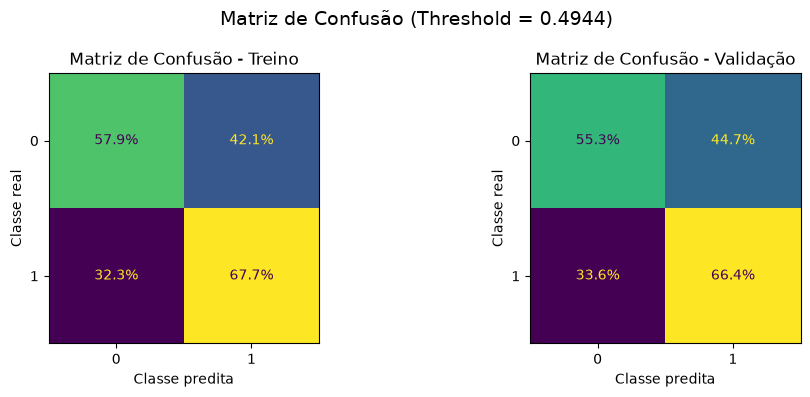

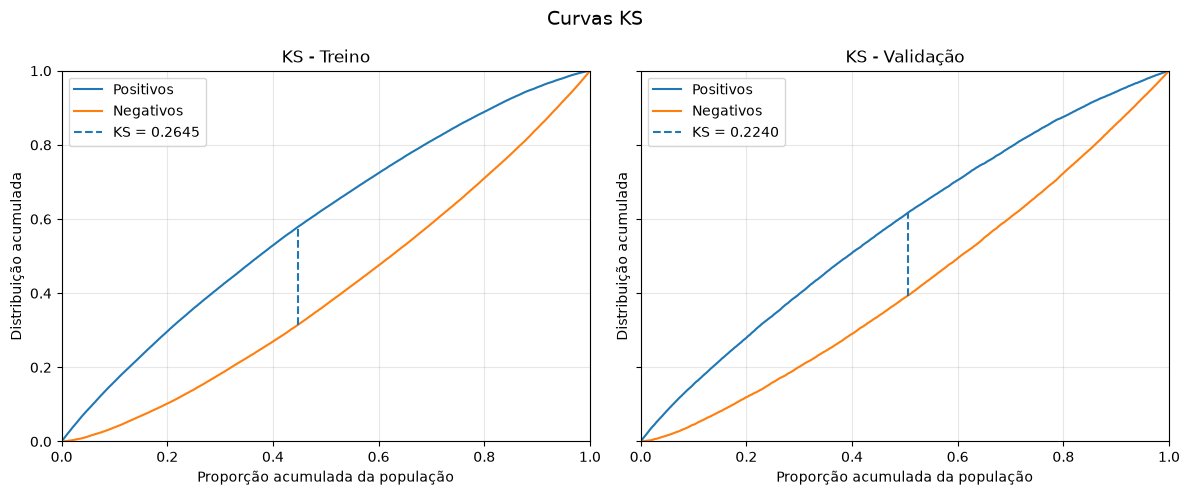

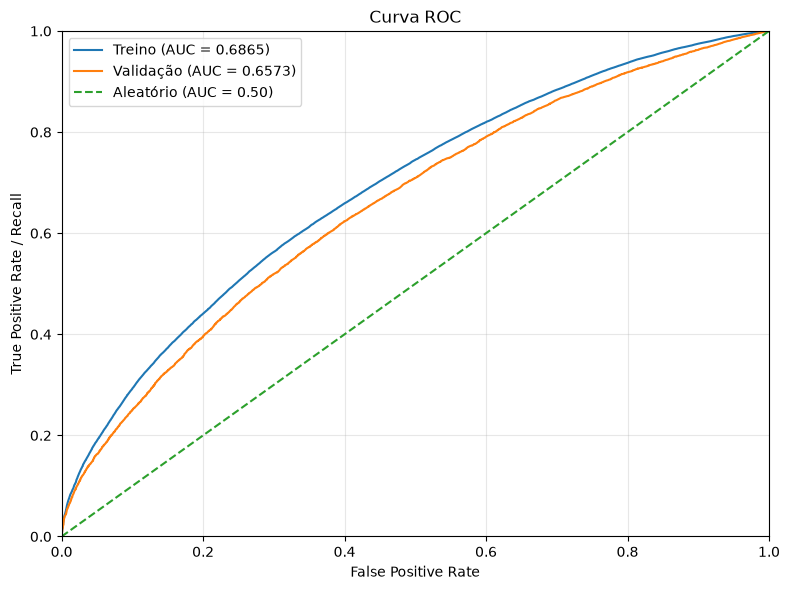

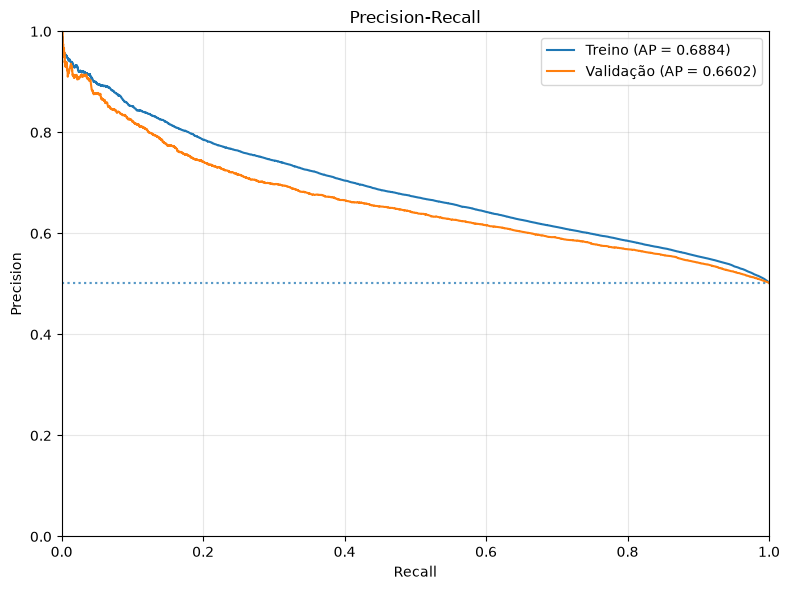


Importância por permutação (Validação)



,Variável,Importância média,Desvio padrão
0,regiao,0.0841,0.0027
1,sigla_uf,0.0747,0.0022
2,populacao,0.0185,0.0012
3,pib,0.0113,0.0008
4,escolaridade,0.0106,0.0006
5,id_escola,0.0091,0.0006
6,rede_desc,0.0085,0.0004
7,escolaridade_formacao,0.0064,0.0004
8,caracterizacao_orgao_gestor,0.0029,0.0003
9,recusa,0.0000,0.0000


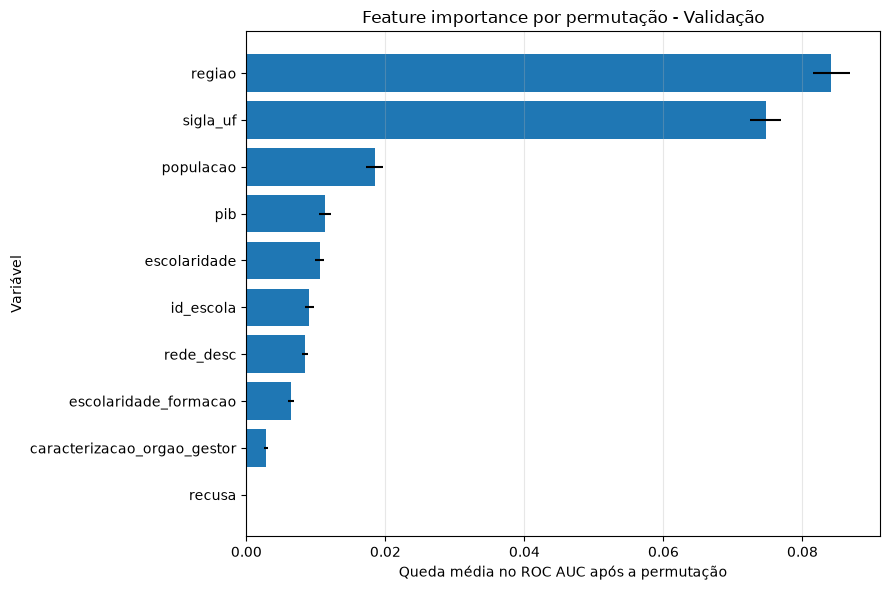

PermutationExplainer explainer: 201it [01:21,  2.18it/s]                         


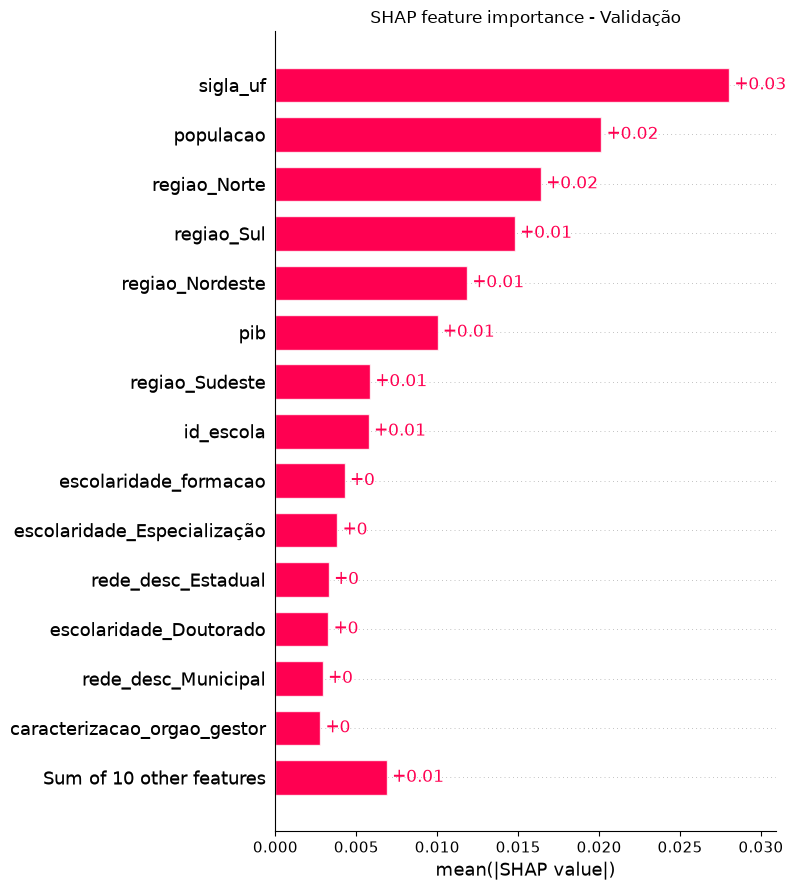

In [51]:
MODEL_TO_INSPECT = validation_comparison.iloc[0]["Modelo"]
model_to_inspect = best_models[MODEL_TO_INSPECT]

print("Modelo em inspeção:", MODEL_TO_INSPECT)

metrics_dev, threshold = evaluate_model(
    model=model_to_inspect,
    datasets=datasets_dev,
    threshold="recall",
    threshold_dataset="Validação",
    save_images=False,
    image_suffix=f"{MODEL_TO_INSPECT}_val",
    interpretability=True
)

## Escolha do modelo campeão e teste

Modelo em inspeção: Random Forest
Threshold fixo utilizado: 0.4944

Métricas do modelo



,Recall,Precision,F1-Score,Accuracy,AUC,KS,Average Precision,Prevalência
Dataset,,,,,,,,
Teste,0.5363,0.6080,0.5699,0.5774,0.6200,0.1645,0.6407,0.5221


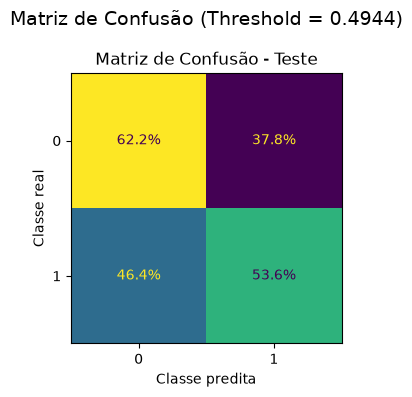

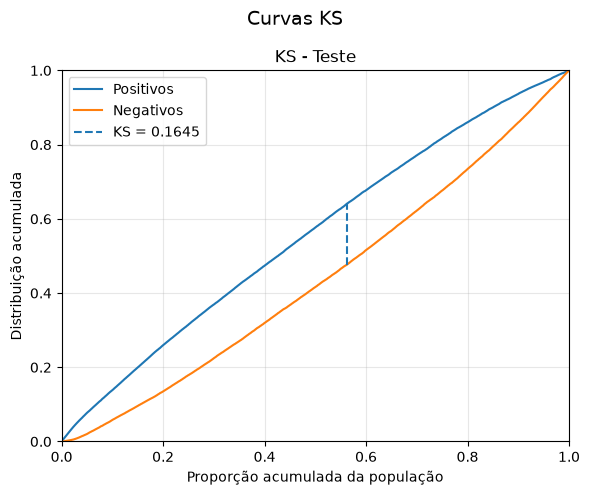

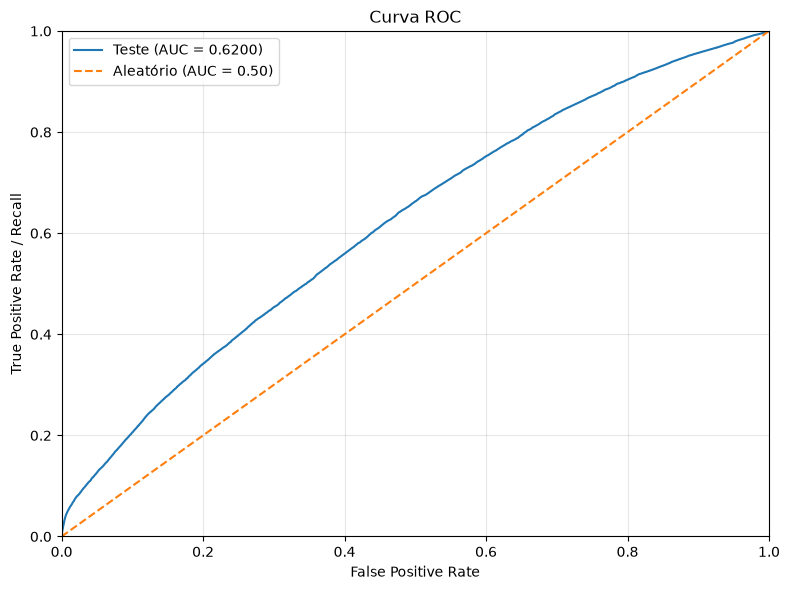

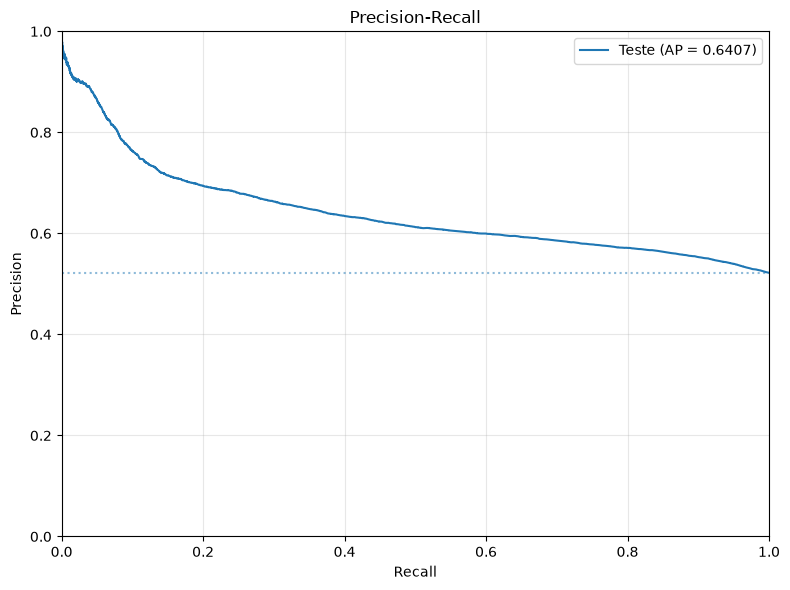


Importância por permutação (Teste)



,Variável,Importância média,Desvio padrão
0,sigla_uf,0.0690,0.0006
1,regiao,0.0606,0.0007
2,populacao,0.0164,0.0004
3,rede_desc,0.0100,0.0004
4,escolaridade,0.0089,0.0002
5,pib,0.0084,0.0002
6,escolaridade_formacao,0.0041,0.0003
7,id_escola,0.0017,0.0003
8,caracterizacao_orgao_gestor,0.0014,0.0001
9,recusa,0.0000,0.0000


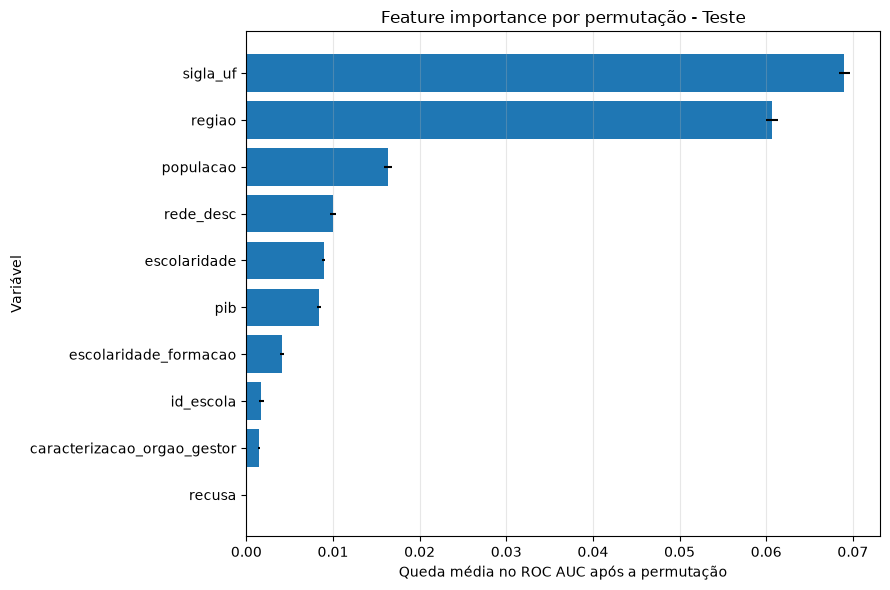

PermutationExplainer explainer: 201it [01:18,  2.24it/s]                         


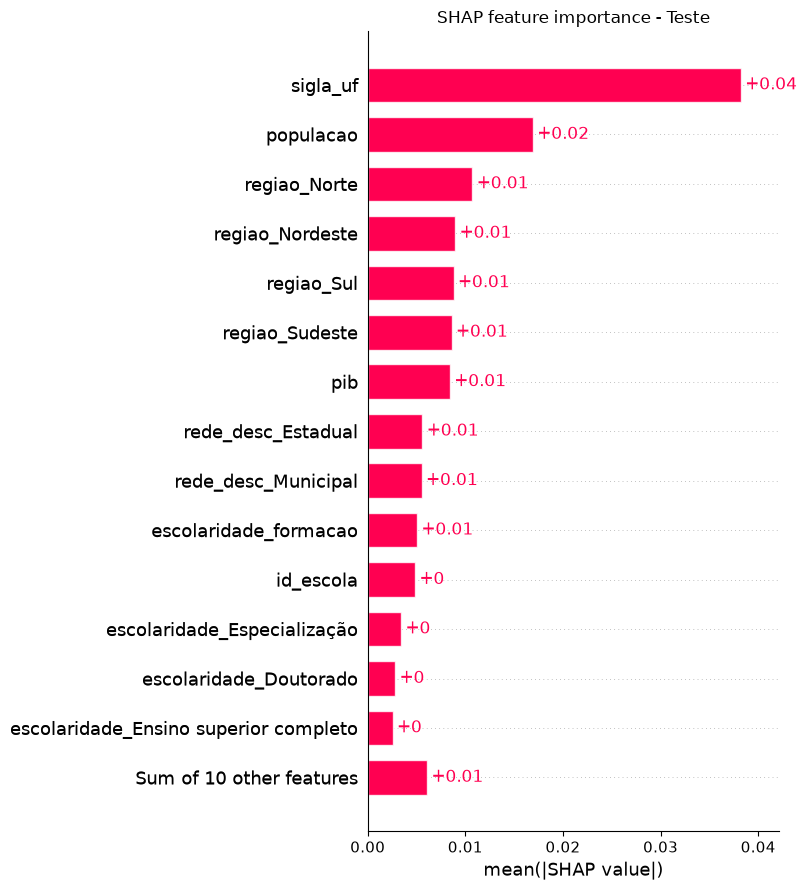

In [52]:
MODEL_TO_INSPECT = validation_comparison.iloc[0]["Modelo"]
model_to_inspect = best_models[MODEL_TO_INSPECT]

print("Modelo em inspeção:", MODEL_TO_INSPECT)

metrics_test, threshold = evaluate_model(
    model=model_to_inspect,
    datasets=datasets_test,
    threshold=threshold,
    save_images=False,
    image_suffix=f"{MODEL_TO_INSPECT}_test",
    interpretability=True
)